In [1]:
import tensorflow as tf
import os

print("TensorFlow version:", tf.__version__)

dataset_path = r"E:\Files\Downloads\PlantDiseaseProject\dataset\Plant_leave_diseases_dataset_with_augmentation"

print("Dataset folders:", os.listdir(dataset_path)[:5])

TensorFlow version: 2.21.0
Dataset folders: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Background_without_leaves']


In [2]:
import os

print(os.listdir(dataset_path))

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Background_without_leaves', 'Blueberry___healthy', 'Cherry___healthy', 'Cherry___Powdery_mildew', 'Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust', 'Corn___healthy', 'Corn___Northern_Leaf_Blight', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___healthy', 'Strawberry___Leaf_scorch', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tom

# **LOADING DATASET ( TRAINING & VALIDATION ) **

In [3]:
import tensorflow as tf

img_size = (160, 160)
batch_size = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 61486 files belonging to 39 classes.
Using 49189 files for training.
Found 61486 files belonging to 39 classes.
Using 12297 files for validation.


In [4]:
class_names = train_dataset.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Total Classes:", num_classes)

Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Background_without_leaves', 'Blueberry___healthy', 'Cherry___Powdery_mildew', 'Cherry___healthy', 'Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust', 'Corn___Northern_Leaf_Blight', 'Corn___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_

# **OPTIMIZING** **DATASET**

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

# **VISUALIZING DATASET**

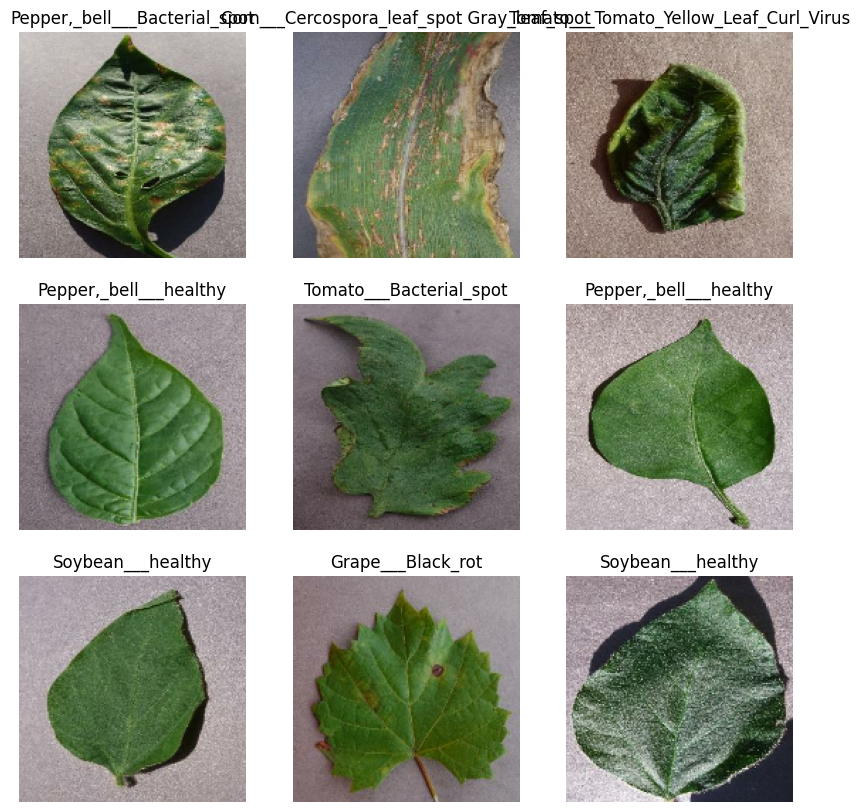

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

# **# Data Augmentation (for real-world robustness)**

In [7]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

# **# # Model 1: Improved CNN with Data Augmentation**

In [8]:
from tensorflow.keras import models

basic_cnn = models.Sequential([
    layers.Input(shape=(160, 160, 3)),

    data_augmentation,   # 🔥 IMPORTANT ADDITION
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

# **COMPILING MODEL**

In [9]:
basic_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# **TRAINING MODEL**

In [10]:
train_dataset_small = train_dataset.take(300)
validation_dataset_small = validation_dataset.take(100)

history_basic = basic_cnn.fit(
    train_dataset_small,
    validation_data=validation_dataset_small,
    epochs=5
)

Epoch 1/5


300/300 ━━━━━━━━━━━━━━━━━━━━ 98s 316ms/step - accuracy: 0.2475 - loss: 2.8673 - val_accuracy: 0.3587 - val_loss: 2.3053
Epoch 2/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 83s 277ms/step - accuracy: 0.3955 - loss: 2.1751 - val_accuracy: 0.5263 - val_loss: 1.7117
Epoch 3/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 83s 278ms/step - accuracy: 0.4757 - loss: 1.8387 - val_accuracy: 0.6081 - val_loss: 1.4027
Epoch 4/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 83s 275ms/step - accuracy: 0.5302 - loss: 1.6229 - val_accuracy: 0.6728 - val_loss: 1.1752
Epoch 5/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 82s 274ms/step - accuracy: 0.5564 - loss: 1.5045 - val_accuracy: 0.6644 - val_loss: 1.1351


Saving the trained model !

In [36]:
basic_cnn.save("models/basic_cnn_model.keras")

# **PLOTTING ACCURACY**

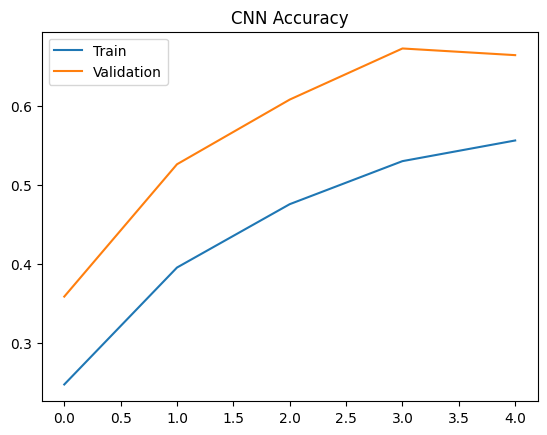

In [11]:
import matplotlib.pyplot as plt

plt.plot(history_basic.history['accuracy'], label='Train')
plt.plot(history_basic.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("CNN Accuracy")
plt.show()

#**# Model 2: Transfer Learning using** **MobileNetV2**

In [12]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [14]:
base_model.trainable = False

# **BUILDING THE MODEL **

In [15]:
model = models.Sequential([
    layers.Input(shape=(160, 160, 3)),

    data_augmentation,   # 🔥 important for real-world
    layers.Rescaling(1./255),

    base_model,

    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

# **COMPILING MODEL **

In [16]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# **TRAINING MODEL**

In [17]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5
)

Epoch 1/5
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 401s 258ms/step - accuracy: 0.7515 - loss: 0.8545 - val_accuracy: 0.8951 - val_loss: 0.3381
Epoch 2/5
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 381s 248ms/step - accuracy: 0.8379 - loss: 0.5194 - val_accuracy: 0.9013 - val_loss: 0.3115
Epoch 3/5
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 359s 233ms/step - accuracy: 0.8496 - loss: 0.4749 - val_accuracy: 0.9092 - val_loss: 0.2833
Epoch 4/5
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 366s 238ms/step - accuracy: 0.8590 - loss: 0.4407 - val_accuracy: 0.9071 - val_loss: 0.2876
Epoch 5/5
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 356s 232ms/step - accuracy: 0.8650 - loss: 0.4280 - val_accuracy: 0.9072 - val_loss: 0.2856


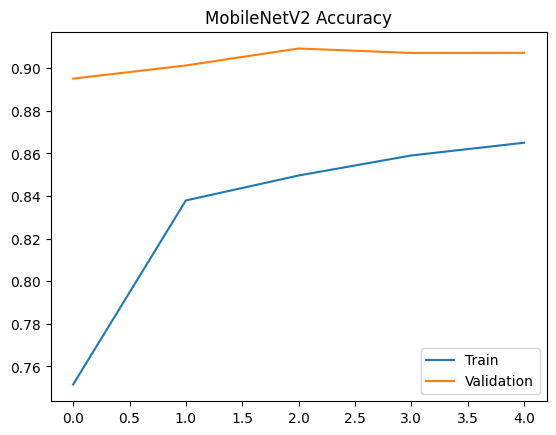

In [18]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("MobileNetV2 Accuracy")
plt.show()

# **FINE TUNING **

In [19]:
base_model.trainable = True

In [20]:
for layer in base_model.layers[:-30]:   # freeze all except last 30 layers
    layer.trainable = False

**COMPILING MODEL**

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**TRAINING THE MODEL**

In [22]:
history_fine = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=3
)

Epoch 1/3
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 490s 314ms/step - accuracy: 0.7955 - loss: 0.6819 - val_accuracy: 0.8983 - val_loss: 0.3470
Epoch 2/3
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 454s 295ms/step - accuracy: 0.8514 - loss: 0.4818 - val_accuracy: 0.9128 - val_loss: 0.2692
Epoch 3/3
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 432s 281ms/step - accuracy: 0.8714 - loss: 0.4111 - val_accuracy: 0.9253 - val_loss: 0.2322


Saving the trained model

In [39]:
import json
import os

os.makedirs("models", exist_ok=True)

with open("models/class_names.json", "w") as f:
    json.dump(class_names, f)

print("Class names saved successfully!")

Class names saved successfully!


In [37]:
model.save("models/mobilenetv2_finetuned.keras")

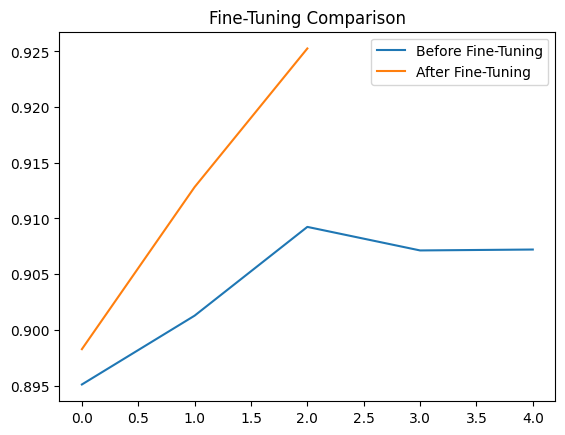

In [23]:
import matplotlib.pyplot as plt

plt.plot(history.history['val_accuracy'], label='Before Fine-Tuning')
plt.plot(history_fine.history['val_accuracy'], label='After Fine-Tuning')

plt.legend()
plt.title("Fine-Tuning Comparison")
plt.show()

# **# Model Evaluation**

**CREATED TEST DATASET**

In [24]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(160,160),
    batch_size=32
)

Found 61486 files belonging to 39 classes.
Using 12297 files for validation.


**Getting True Labels **

In [25]:
import numpy as np

y_true = np.concatenate([y for x, y in test_dataset], axis=0)

# **Predictions**

In [26]:
y_pred_probs = model.predict(test_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

385/385 ━━━━━━━━━━━━━━━━━━━━ 70s 179ms/step


# **CONFUSION MATRIX**

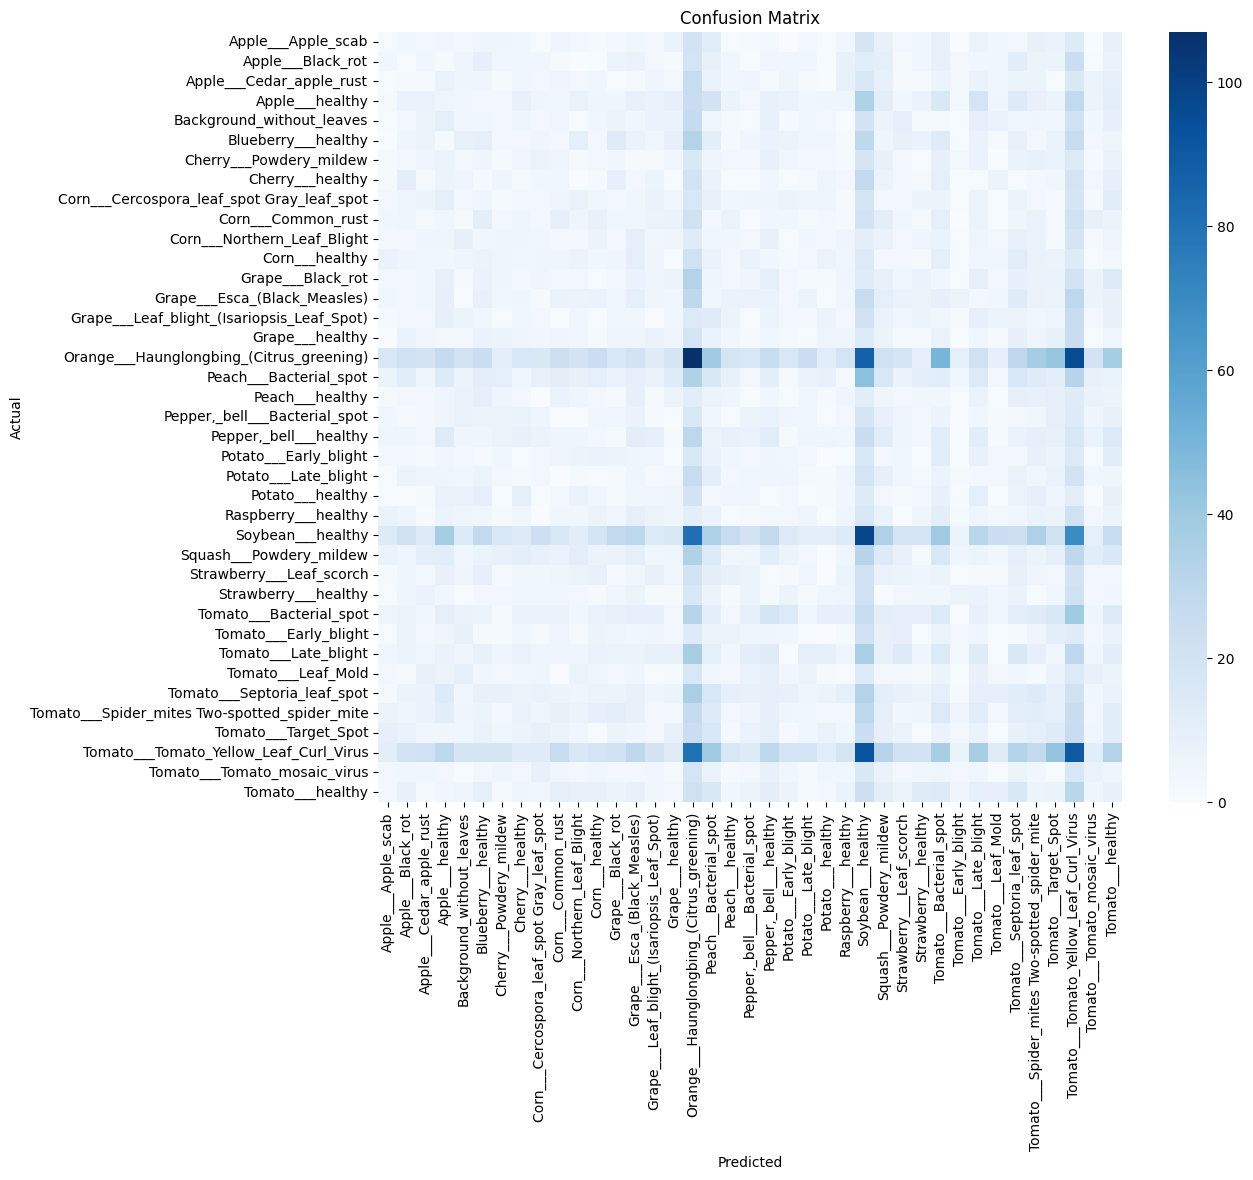

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# **CLASSIFICATION REPORT**

In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))

                                               precision    recall  f1-score   support

                           Apple___Apple_scab       0.01      0.01      0.01       194
                            Apple___Black_rot       0.00      0.00      0.00       214
                     Apple___Cedar_apple_rust       0.01      0.01      0.01       206
                              Apple___healthy       0.01      0.01      0.01       345
                    Background_without_leaves       0.02      0.02      0.02       227
                          Blueberry___healthy       0.03      0.03      0.03       289
                      Cherry___Powdery_mildew       0.01      0.01      0.01       200
                             Cherry___healthy       0.01      0.01      0.01       204
   Corn___Cercospora_leaf_spot Gray_leaf_spot       0.01      0.01      0.01       218
                           Corn___Common_rust       0.04      0.04      0.04       231
                  Corn___Northern_Leaf_Bli

# **Accuracy Comparison Table **

In [31]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Basic CNN", "MobileNetV2 (Before FT)", "MobileNetV2 (After FT)"],
    "Validation Accuracy": [
        history_basic.history['val_accuracy'][-1],
        history.history['val_accuracy'][-1],
        history_fine.history['val_accuracy'][-1]
    ]
})

comparison

,Model,Validation Accuracy
0,Basic CNN,0.664375
1,MobileNetV2 (Before FT),0.907213
2,MobileNetV2 (After FT),0.925266


# **MODEL Parameter Comparison**

In [32]:
print("Basic CNN Parameters:", basic_cnn.count_params())
print("MobileNetV2 Parameters:", model.count_params())

Basic CNN Parameters: 5406823
MobileNetV2 Parameters: 2432103


# **OverFitting Analysis**

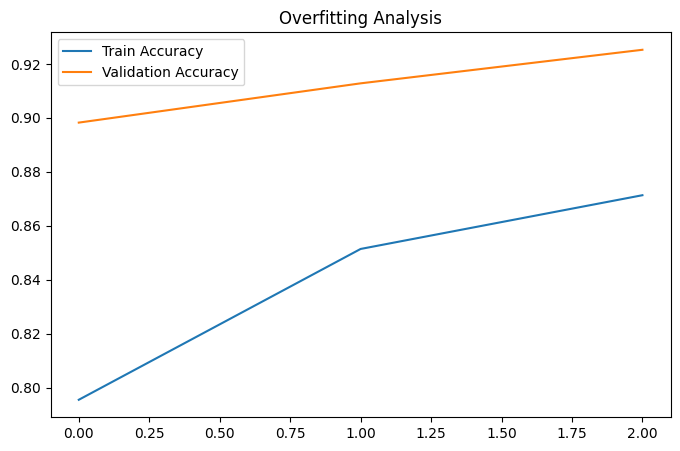

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_fine.history['accuracy'], label='Train Accuracy')  
plt.plot(history_fine.history['val_accuracy'], label='Validation Accuracy')

plt.legend()
plt.title("Overfitting Analysis")
plt.show()

# **Real World Testing **

In [49]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "test_images/testleaf.jpg"

img = image.load_img(img_path, target_size=(160,160))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

In [51]:
prediction = model.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]

print("Prediction:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Prediction: Background_without_leaves


(np.float64(-0.5), np.float64(159.5), np.float64(159.5), np.float64(-0.5))

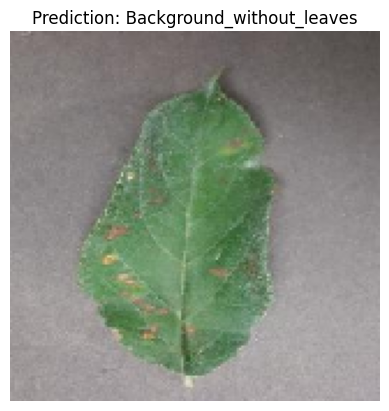

In [52]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"Prediction: {predicted_class}")
plt.axis("off")

# **ADDING Grad CAM Function**